In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

In [3]:
train_normal=len(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL'))
train_pneumonia=len(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA'))
print(f'Normal: {train_normal}, Pnuemonia: {train_pneumonia}')

Normal: 1341, Pnuemonia: 3875


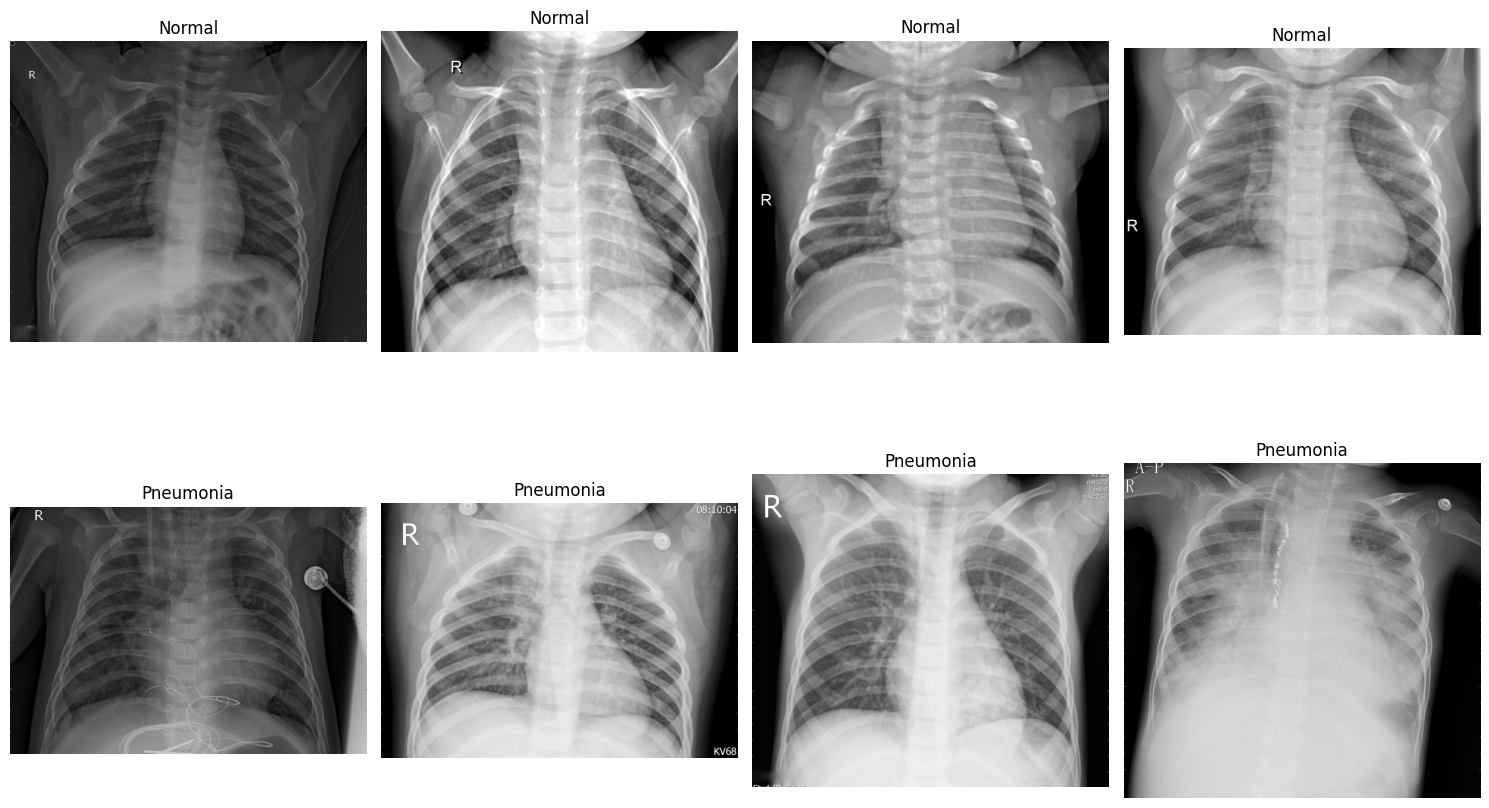

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

normal_dir='/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL'
pneumonia_dir='/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA'

fig, axes = plt.subplots(2, 4, figsize=(15, 10))
for i, ax in enumerate(axes[0]):
    img=mpimg.imread(os.path.join(normal_dir, os.listdir(normal_dir)[i]))
    ax.imshow(img, cmap='gray')
    ax.set_title('Normal')
    ax.axis('off')
for i, ax in enumerate(axes[1]):
    img=mpimg.imread(os.path.join(pneumonia_dir, os.listdir(pneumonia_dir)[i]))
    ax.imshow(img, cmap='gray')
    ax.set_title('Pneumonia')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
from PIL import Image 
img=Image.open(os.path.join(normal_dir, os.listdir(normal_dir)[0]))
print(img.size, img.mode)

(1336, 1128) L


In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
from torch.utils.data import ConcatDataset, random_split

# Increasing validation instances
train_raw = datasets.ImageFolder('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train')
val_raw = datasets.ImageFolder('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val')
full_train = ConcatDataset([train_raw, val_raw])
train_size=int(0.8*len(full_train))
val_size=len(full_train)-train_size
train_subset, val_subset = random_split(full_train, [train_size, val_size])
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return self.transform(x), y
    def __len__(self):
        return len(self.subset)
        
train_dataset = TransformSubset(train_subset, train_transform)
val_dataset = TransformSubset(val_subset, val_transform)
test_dataset = datasets.ImageFolder('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test',
                                   transform=val_transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader= DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader= DataLoader(test_dataset, batch_size=32, shuffle=False)

In [9]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
print(labels.unique())

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([0, 1])


In [10]:
import torch.nn as nn

class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )

        self.flatten=nn.Flatten()

        self.lin=nn.Sequential(
            nn.Linear(128*28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x=self.conv(x)
        x=self.flatten(x)
        x=self.lin(x)
        return x

In [11]:
model = BaseCNN()
x = torch.randn(32, 3, 224, 224)  # fake batch
out = model(x)
print(out.shape)  # should be [32, 2]

torch.Size([32, 2])


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BaseCNN().to(device)

In [13]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=0.001)

In [14]:
for epoch in range(10):
    model.train()
    train_loss=0.0
    correct_train=0
    total_train=0
    for images, labels in train_loader:
        #forward pass
        images, labels = images.to(device), labels.to(device)
        outputs=model(images)
        loss=criterion(outputs, labels)
        print(loss)

        #backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()*images.size(0)
        print(train_loss)

        _, predictions = torch.max(outputs, 1)
        correct_train+=(predictions==labels).sum().item()
        total_train+=labels.size(0)
        print(total_train)
        break
    epoch_train_loss=train_loss/len(train_loader.dataset)
    epoch_train_acc=correct_train/total_train
    print(epoch_train_loss)
    print(epoch_train_acc)
    break

tensor(0.6812, device='cuda:0', grad_fn=<NllLossBackward0>)
21.79832649230957
32
0.00520868016542642
0.65625


In [15]:
model.eval()
images, labels = next(iter(train_loader))
images = images.to(device)
with torch.no_grad():
    out = model(images)
    print(out[:5])  # first 5 logits
    print(out.std())  # how spread out are the logits (they are very spread out)

tensor([[-6.2702,  8.4030],
        [-8.6786, 11.8374],
        [-6.6336,  9.2187],
        [-7.6374, 10.5625],
        [-8.5333, 11.4226]], device='cuda:0')
tensor(8.7731, device='cuda:0')


In [16]:
model = BaseCNN().to(device)

# scale down output layer weights
with torch.no_grad():
    model.lin[-1].weight *= 0.1
    model.lin[-1].bias *= 0.1

# weight Normal class higher to penalize false positives more
class_weights = torch.tensor([3.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)   #class imbalance pneumonia is 3times more than normal
optimizer=torch.optim.Adam(model.parameters(), lr=0.0001)

In [17]:
model.eval()
images, labels = next(iter(train_loader))
images = images.to(device)
with torch.no_grad():
    out = model(images)
    print(out[:5])  # first 5 logits
    print(out.std())

tensor([[-0.0041,  0.0028],
        [-0.0058,  0.0041],
        [-0.0055,  0.0046],
        [-0.0044,  0.0036],
        [-0.0052,  0.0042]], device='cuda:0')
tensor(0.0044, device='cuda:0')


In [18]:
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)
optimizer.zero_grad()
outputs = model(images)
loss = criterion(outputs, labels)
loss.backward()
print(model.lin[-1].weight.grad.abs().max()) #tensor(180.9732, device='cuda:0')
                                             #tensor(8.9744, device='cuda:0') 
#as you can see the gradients were exploding. Used gradient clipping above
print(model.conv[0].weight.grad.abs().max())  

tensor(0.0214, device='cuda:0')
tensor(0.0004, device='cuda:0')


In [20]:
best_val_loss=float('inf')
for epoch in range(10):
    model.train()
    train_loss=0.0
    correct_train=0
    total_train=0
    for images, labels in train_loader:
        #forward pass
        images, labels = images.to(device), labels.to(device)
        outputs=model(images)
        loss=criterion(outputs, labels)

        #backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss+=loss.item()*images.size(0)

        _, predictions = torch.max(outputs, 1)
        correct_train+=(predictions==labels).sum().item()
        total_train+=labels.size(0)
        
    epoch_train_loss=train_loss/len(train_loader.dataset)
    epoch_train_acc=correct_train/total_train

    model.eval()
    val_loss=0.0
    correct_val=0
    total_val=0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs=model(images)
            loss=criterion(outputs, labels)
    
            val_loss+=loss.item()*images.size(0)
            _, predictions=torch.max(outputs, 1)
            correct_val+=(predictions==labels).sum().item()
            total_val+=labels.size(0)
        epoch_val_loss=val_loss/len(val_loader.dataset)
        epoch_val_acc=correct_val/total_val

    print(f'Epoch {epoch+1}/10 | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}')

Epoch 1/10 | Train Loss: 0.1865 | Train Acc: 0.9343 | Val Loss: 0.1861 | Val Acc: 0.9570
Epoch 2/10 | Train Loss: 0.1645 | Train Acc: 0.9446 | Val Loss: 0.1446 | Val Acc: 0.9628
Epoch 3/10 | Train Loss: 0.1379 | Train Acc: 0.9517 | Val Loss: 0.2165 | Val Acc: 0.9599
Epoch 4/10 | Train Loss: 0.1349 | Train Acc: 0.9582 | Val Loss: 0.1953 | Val Acc: 0.9150
Epoch 5/10 | Train Loss: 0.1367 | Train Acc: 0.9579 | Val Loss: 0.0973 | Val Acc: 0.9647
Epoch 6/10 | Train Loss: 0.1219 | Train Acc: 0.9615 | Val Loss: 0.1029 | Val Acc: 0.9656
Epoch 7/10 | Train Loss: 0.1242 | Train Acc: 0.9620 | Val Loss: 0.0837 | Val Acc: 0.9666
Epoch 8/10 | Train Loss: 0.1226 | Train Acc: 0.9634 | Val Loss: 0.1612 | Val Acc: 0.9666
Epoch 9/10 | Train Loss: 0.1144 | Train Acc: 0.9658 | Val Loss: 0.1043 | Val Acc: 0.9522
Epoch 10/10 | Train Loss: 0.1183 | Train Acc: 0.9661 | Val Loss: 0.1009 | Val Acc: 0.9561


In [21]:
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        _, predictions = torch.max(outputs, 1)
        correct_test += (predictions == labels).sum().item()
        total_test += labels.size(0)
print(f'Test Loss: {test_loss/len(test_loader.dataset):.4f} | Test Acc: {correct_test/total_test:.4f}')

Test Loss: 0.5570 | Test Acc: 0.8317


In [22]:
from sklearn.metrics import confusion_matrix, classification_report
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia']))

[[145  89]
 [ 16 374]]
              precision    recall  f1-score   support

      Normal       0.90      0.62      0.73       234
   Pneumonia       0.81      0.96      0.88       390

    accuracy                           0.83       624
   macro avg       0.85      0.79      0.81       624
weighted avg       0.84      0.83      0.82       624



In [23]:
from sklearn.metrics import roc_auc_score

all_probs = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of Pneumonia class
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

auc = roc_auc_score(all_labels, all_probs)
print(f'AUC-ROC: {auc:.4f}')

AUC-ROC: 0.9274


In [24]:
# Test accuracy: 83%
# Normal recall: 62%
# Pneumonia recall: 96%
# Macro F1: 0.81
# AUC-ROC: 0.927